# HF TDOA Analysis - Figures 13
This notebook uses the `hf_tdoa` library to analyze HF TDOA measurements and generate Figure 13.

In [1]:
import os
import datetime
import importlib
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [2]:
base_dir   = '../data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('../data/templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: N6RFM (EM12jw), Range: 407.3 km, Band: 7 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 39
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 39/39 [00:03<00:00, 11.08file/s, Chirps=10, Max Corr=4.61e+03]

✓ Completed chirp detection: 39 files processed, 390 total chirps found



## Find TDOAs

In [4]:
debug_TDOAs = False

# Find TDOAs for each propagation mode using the simplified API
# The mode configurations (filter limits, search limits, model coefficients, and plotting params)
# are now stored in hf_tdoa_lib.MODE_CONFIGS

# Process all three modes
for mode_string in ['2F2-1F2', '1F2-1E', '2F2-1E']:
    chirps = tdoa.find_TDOAs(chirps, mode_string=mode_string,
                            plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary with model coefficients and plotting parameters
tdoa_dct = tdoa.build_tdoa_config(chirps)


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (2F2-1F2): 100%|██████████| 39/39 [00:12<00:00,  3.12file/s, Mean TDOA=1.65 ms]


✓ Completed processing 2F2-1F2: 39 files processed


Processing Mode: 1F2-1E
  Filter Limits:  2.5 - 30.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     5.0 - 12.0 Hz
  Set Name:       1F2-1E
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (1F2-1E): 100%|██████████| 39/39 [00:12<00:00,  3.11file/s, Mean TDOA=0.98 ms]


✓ Completed processing 1F2-1E: 39 files processed


Processing Mode: 2F2-1E
  Filter Limits:  20.0 - 30.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     22.0 - 30.0 Hz
  Set Name:       2F2-1E
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (2F2-1E): 100%|██████████| 39/39 [00:13<00:00,  2.91file/s, Mean TDOA=2.56 ms]


✓ Completed processing 2F2-1E: 39 files processed


Path Information
  PathInfo(TX: WA5FRF (EL09nn), RX: N6RFM (EM12jw), Range: 407.3 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 32.938°N, -97.208°E (EM12jw)

Path Midpoint: 31.253°N, -98.057°E

Path Azimuth (TX→RX): 22.5°

Calculated TDOA Model Coefficients:
2F2-1F2      (2F2-1F2 ): slope= 141.0, intercept=  46.6
1F2-1E       (1F2-1E  ): slope= 181.3, intercept= 136.2
2F2-1E       (2F2-1E  ): slope=  79.3, intercept=  85.7



## Figure 13 - TDOA Measurements and Layer Heights

This figure combines TDOA measurements (a) and layer heights comparison with ionosonde (b) in a single figure with two subplots.

Figure saved to: fig_13.jpg


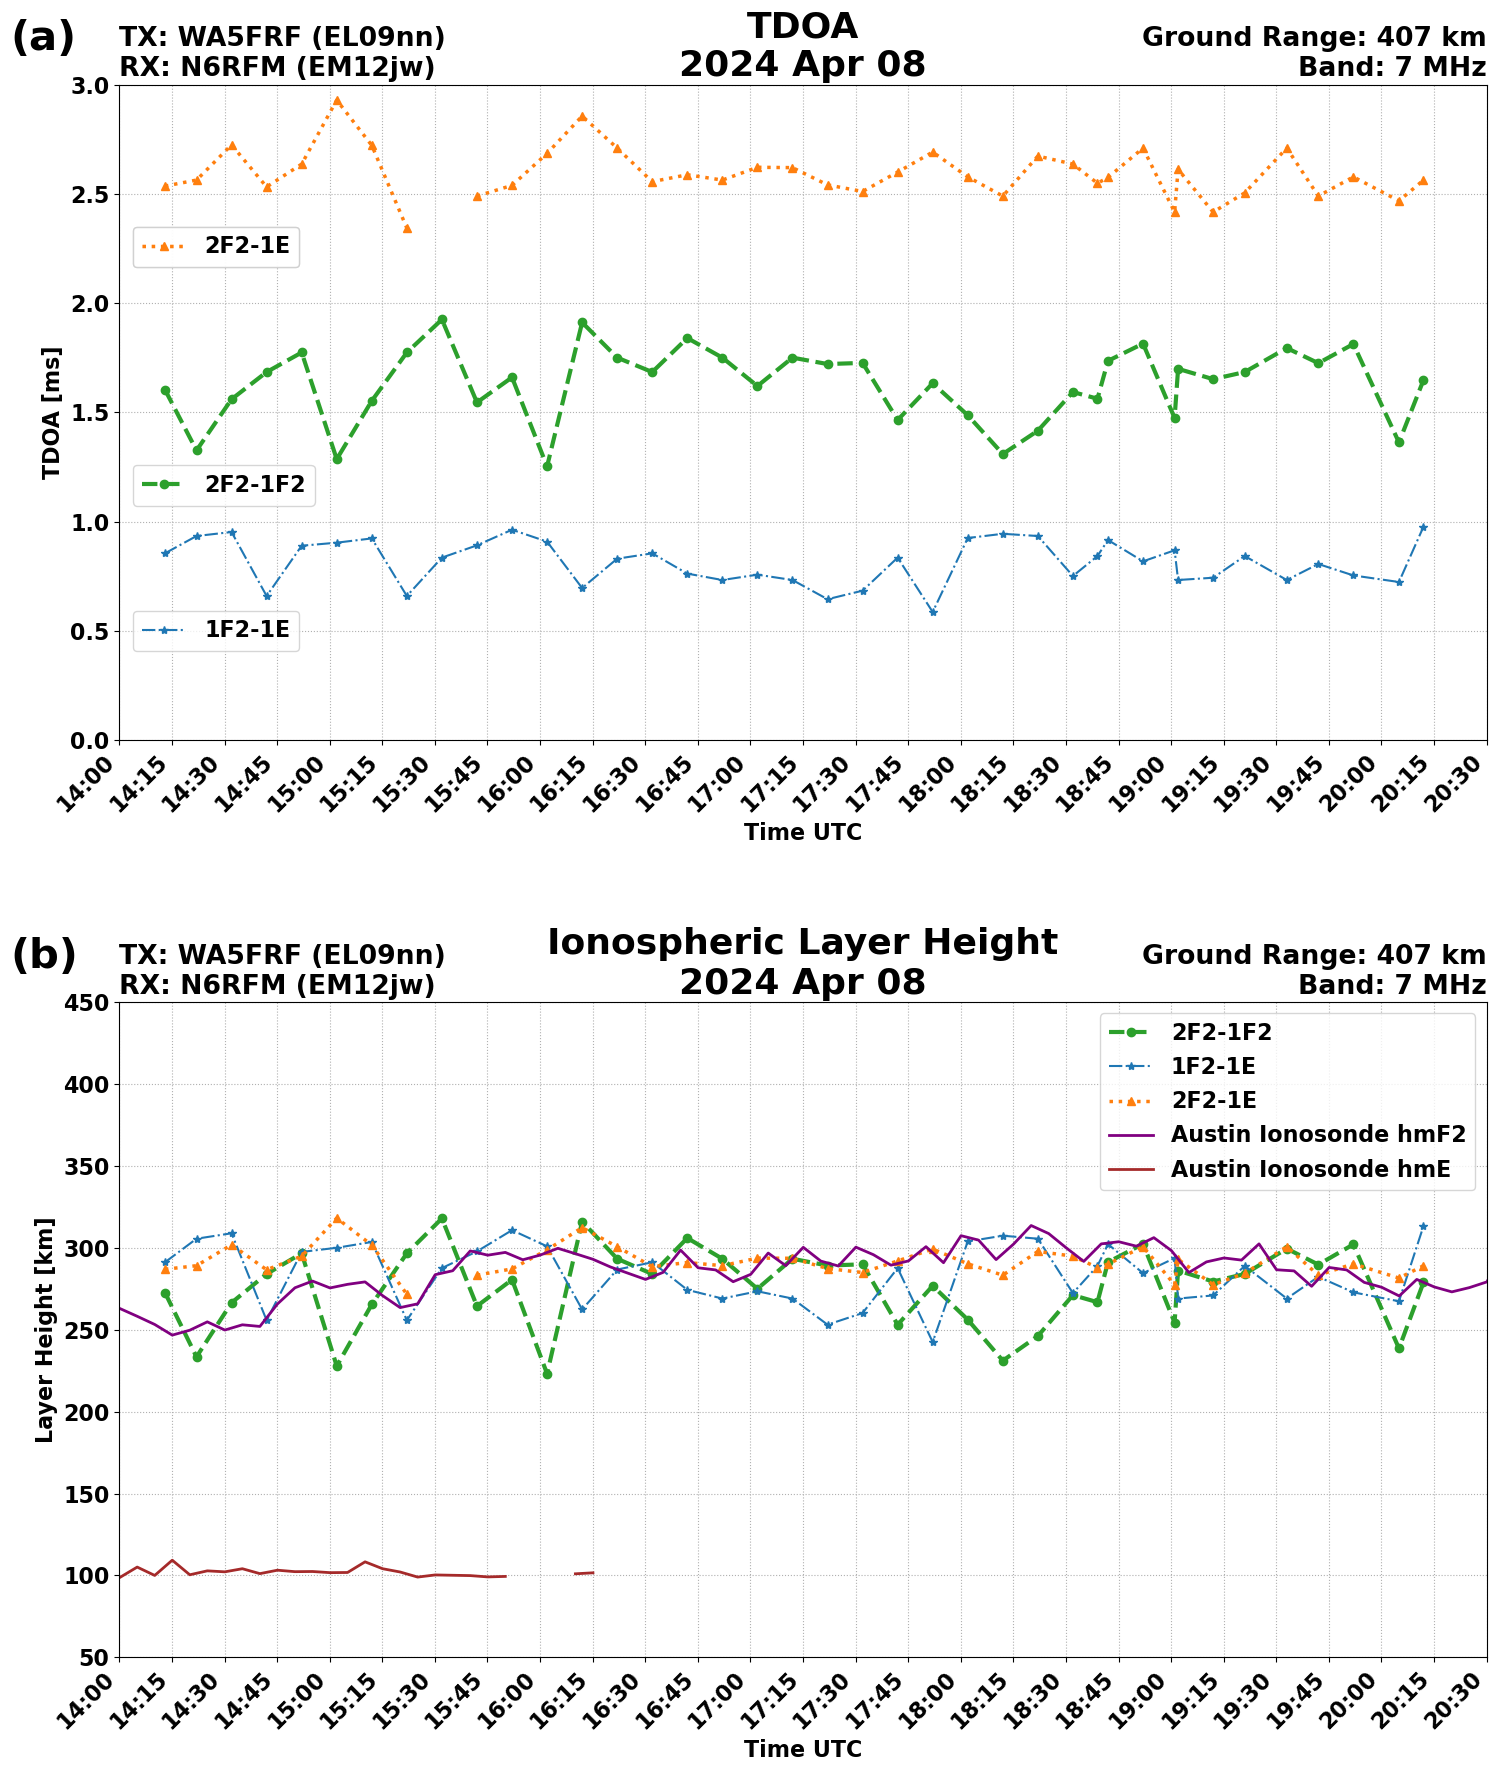

In [5]:
# Set time limits for consistent x-axis across subplots
xlim = (datetime.datetime(2024, 4, 8, 14, 0), datetime.datetime(2024, 4, 8, 20, 30))

tdoa.plot_tdoa_hmf2_subplot(chirps, tdoa_dct, 
                            xlim=xlim,
                            ylim_tdoa=(0,3),
                            ylim_hmf2=(50, 450),
                            ionosonde_dct=True,
                            figsize=(15, 18),
                            savefig='fig_13.jpg')